# Experiment 1: Baseline
**Baseline:** Single DecisionTree, DecisionStump, and sklearn comparison.

In [1]:
# === Imports and Setup ===
import sys
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 120

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from src.utils.preprocessing import standardize, train_test_split
from src.metrics.evaluation import (
    accuracy_calculation, f1_score, auc_roc
)
from src.trees.decision_tree import DecisionTree
from src.trees.boosting.adaboost import DecisionStump
from sklearn.tree import DecisionTreeClassifier as SkDT

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1. Load Dataset

Using all data set


In [2]:
from src.utils.preprocessing import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Classes: {np.unique(y)} ({len(np.unique(y))} classes)")
print(f"Class distribution: {np.bincount(y)}")

from src.utils.preprocessing import load_adult_income_data
X_adult, y_adult, df_adult = load_adult_income_data()
Z = X_adult
t = y_adult.str.strip().map({
    '<=50K': 0,
    '>50K': 1
}).values
print(f"Samples: {Z.shape[0]}, Features: {Z.shape[1]}")
print(f"Classes: {np.unique(t)} ({len(np.unique(t))} classes)")
print(f"Class distribution: {np.bincount(t)}")

from src.utils.preprocessing import load_covertype_data
A, b, df_cover = load_covertype_data()
# y DataFrame olduğu üçün sütunu götürürük
b = b.values
print(f"Samples: {A.shape[0]}, Features: {A.shape[1]}")
print(f"Classes: {np.unique(b)} ({len(np.unique(b))} classes)")
print(f"Class distribution: {np.bincount(b)}")

from src.utils.preprocessing import load_mnist_data
M, n, df_mnist = load_mnist_data()
n = n.values 
print(f"Samples: {M.shape[0]}, Features: {M.shape[1]}")
print(f"Classes: {np.unique(n)} ({len(np.unique(n))} classes)")
print(f"Class distribution: {np.bincount(n)}")

Samples: 569, Features: 30
Classes: [0 1] (2 classes)
Class distribution: [212 357]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/adult_income.parquet
Samples: 48842, Features: 6
Classes: [0 1] (2 classes)
Class distribution: [37155 11687]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/covertype.parquet
Samples: 581012, Features: 10
Classes: [1 2 3 4 5 6 7] (7 classes)
Class distribution: [     0 211840 283301  35754   2747   9493  17367  20510]
Loaded from Parquet: /Users/student/Desktop/ML_PROJECT-main/data/mnist.parquet
Samples: 70000, Features: 784
Classes: [0 1 2 3 4 5 6 7 8 9] (10 classes)
Class distribution: [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


---
## 2. Experiment 1: Baseline

80/20 train/test split. Train unpruned DecisionTree, stump, and sklearn DT.
Report accuracy, macro F1, AUC-ROC. Verify within 2% of sklearn.

In [3]:
datasets = {
    "Breast Cancer": (np.asarray(X), np.asarray(y)),
    "Adult Income": (np.asarray(Z), np.asarray(t)),
    "Covertype": (np.asarray(A), np.asarray(b).ravel()),
    "MNIST": (np.asarray(M), np.asarray(n)),
}
all_baseline_results = {}
for name, (X_data, y_data) in datasets.items():
    print(f"\n{'='*60}")
    print(name)
    print(f"{'='*60}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data,
        test_size=0.2,
        random_state=RANDOM_STATE
    )

    X_train_s, X_test_s = standardize(X_train, X_test)

    results = {}

    # Our Decision Tree
    dt = DecisionTree(random_state=RANDOM_STATE)
    dt.fit(X_train_s, y_train)

    pred = dt.predict(X_test_s)
    proba = dt.predict_proba(X_test_s)

    results["DT"] = {
        "acc": accuracy_calculation(y_test, pred),
        "f1": f1_score(y_test, pred, mean="macro"),
        "auc": auc_roc(y_test, proba),
    }

    # Decision Stump
    stump = DecisionStump(random_state=RANDOM_STATE)
    stump.fit(X_train_s, y_train)

    pred_s = stump.predict(X_test_s)
    proba_s = stump.predict_proba(X_test_s)

    results["Stump"] = {
        "acc": accuracy_calculation(y_test, pred_s),
        "f1": f1_score(y_test, pred_s, mean="macro"),
        "auc": auc_roc(y_test, proba_s),
    }

    # sklearn Tree
    sk_dt = SkDT(random_state=RANDOM_STATE)
    sk_dt.fit(X_train_s, y_train)

    sk_pred = sk_dt.predict(X_test_s)
    sk_proba = sk_dt.predict_proba(X_test_s)

    results["sklearn DT"] = {
        "acc": accuracy_calculation(y_test, sk_pred),
        "f1": f1_score(y_test, sk_pred, mean="macro"),
        "auc": auc_roc(y_test, sk_proba),
    }

    print(f'DecisionTree (ours): '
          f'Acc={results["DT"]["acc"]:.4f}, '
          f'F1={results["DT"]["f1"]:.4f}, '
          f'AUC={results["DT"]["auc"]:.4f}')

    print(f'DecisionStump:      '
          f'Acc={results["Stump"]["acc"]:.4f}, '
          f'F1={results["Stump"]["f1"]:.4f}, '
          f'AUC={results["Stump"]["auc"]:.4f}')

    print(f'sklearn Tree:       '
          f'Acc={results["sklearn DT"]["acc"]:.4f}, '
          f'F1={results["sklearn DT"]["f1"]:.4f}, '
          f'AUC={results["sklearn DT"]["auc"]:.4f}')

    diff_pct = abs(results["DT"]["acc"] - results["sklearn DT"]["acc"]) \
               / max(results["sklearn DT"]["acc"], 1e-10) * 100

    status = "PASS" if diff_pct <= 2 else "FAIL"

    print(f'Accuracy difference vs sklearn: {diff_pct:.2f}% ({status})')
    all_baseline_results[name] = results



Breast Cancer
DecisionTree (ours): Acc=0.9561, F1=0.9539, AUC=0.9468
DecisionStump:      Acc=0.8684, F1=0.8579, AUC=0.8468
sklearn Tree:       Acc=0.9386, F1=0.9364, AUC=0.9351
Accuracy difference vs sklearn: 1.87% (PASS)

Adult Income
DecisionTree (ours): Acc=0.7783, F1=0.6981, AUC=0.6997
DecisionStump:      Acc=0.8033, F1=0.6027, AUC=0.5945
sklearn Tree:       Acc=0.7763, F1=0.6969, AUC=0.6996
Accuracy difference vs sklearn: 0.25% (PASS)

Covertype
DecisionTree (ours): Acc=0.9178, F1=0.8733, AUC=0.9265
DecisionStump:      Acc=0.6335, F1=0.1951, AUC=0.7254
sklearn Tree:       Acc=0.9189, F1=0.8729, AUC=0.9258
Accuracy difference vs sklearn: 0.13% (PASS)

MNIST
DecisionTree (ours): Acc=0.8749, F1=0.8734, AUC=0.9298
DecisionStump:      Acc=0.1982, F1=0.0697, AUC=0.6371
sklearn Tree:       Acc=0.8758, F1=0.8742, AUC=0.9302
Accuracy difference vs sklearn: 0.10% (PASS)


In [4]:
def plot_baseline_results(results_dict):
    datasets = list(results_dict.keys())
    models = ["DT", "Stump", "sklearn DT"]
    metrics = ["acc", "f1", "auc"]
    metric_names = ["Accuracy", "F1-Score", "AUC-ROC"]

    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=False)

    x = np.arange(len(datasets))
    width = 0.25

    for idx, metric in enumerate(metrics):
        ax = axes[idx]

        for m_idx, model in enumerate(models):
            means = [results_dict[dataset][model][metric] for dataset in datasets]
            rects = ax.bar(
                x + (m_idx - 1) * width,
                means,
                width,
                label=model,
                color=colors[m_idx],
                alpha=0.85,
            )
            ax.bar_label(rects, padding=3, fmt="%.2f", fontsize=9)

        ax.set_ylabel(metric_names[idx], fontsize=12, fontweight="bold")
        ax.set_title(
            f"Models Comparison based on {metric_names[idx]}",
            fontsize=14,
            fontweight="bold",
            pad=15,
        )
        ax.set_xticks(x)
        ax.set_xticklabels(datasets, fontsize=11)
        ax.set_ylim(0, 1.15)
        ax.grid(axis="y", linestyle="--", alpha=0.7)

        if idx == 0:
            ax.legend(loc="upper right", fontsize=11)

    plt.tight_layout()

    # Notebook-un olduğu qovluq
    notebook_dir = os.getcwd()

    # Paralel yerləşən figures qovluğu
    figures_dir = os.path.join(os.path.dirname(notebook_dir), "figures")
    os.makedirs(figures_dir, exist_ok=True)

    # Şəkli saxla
    save_path = os.path.join(figures_dir, "baseline_results.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Figure saved to: {save_path}")

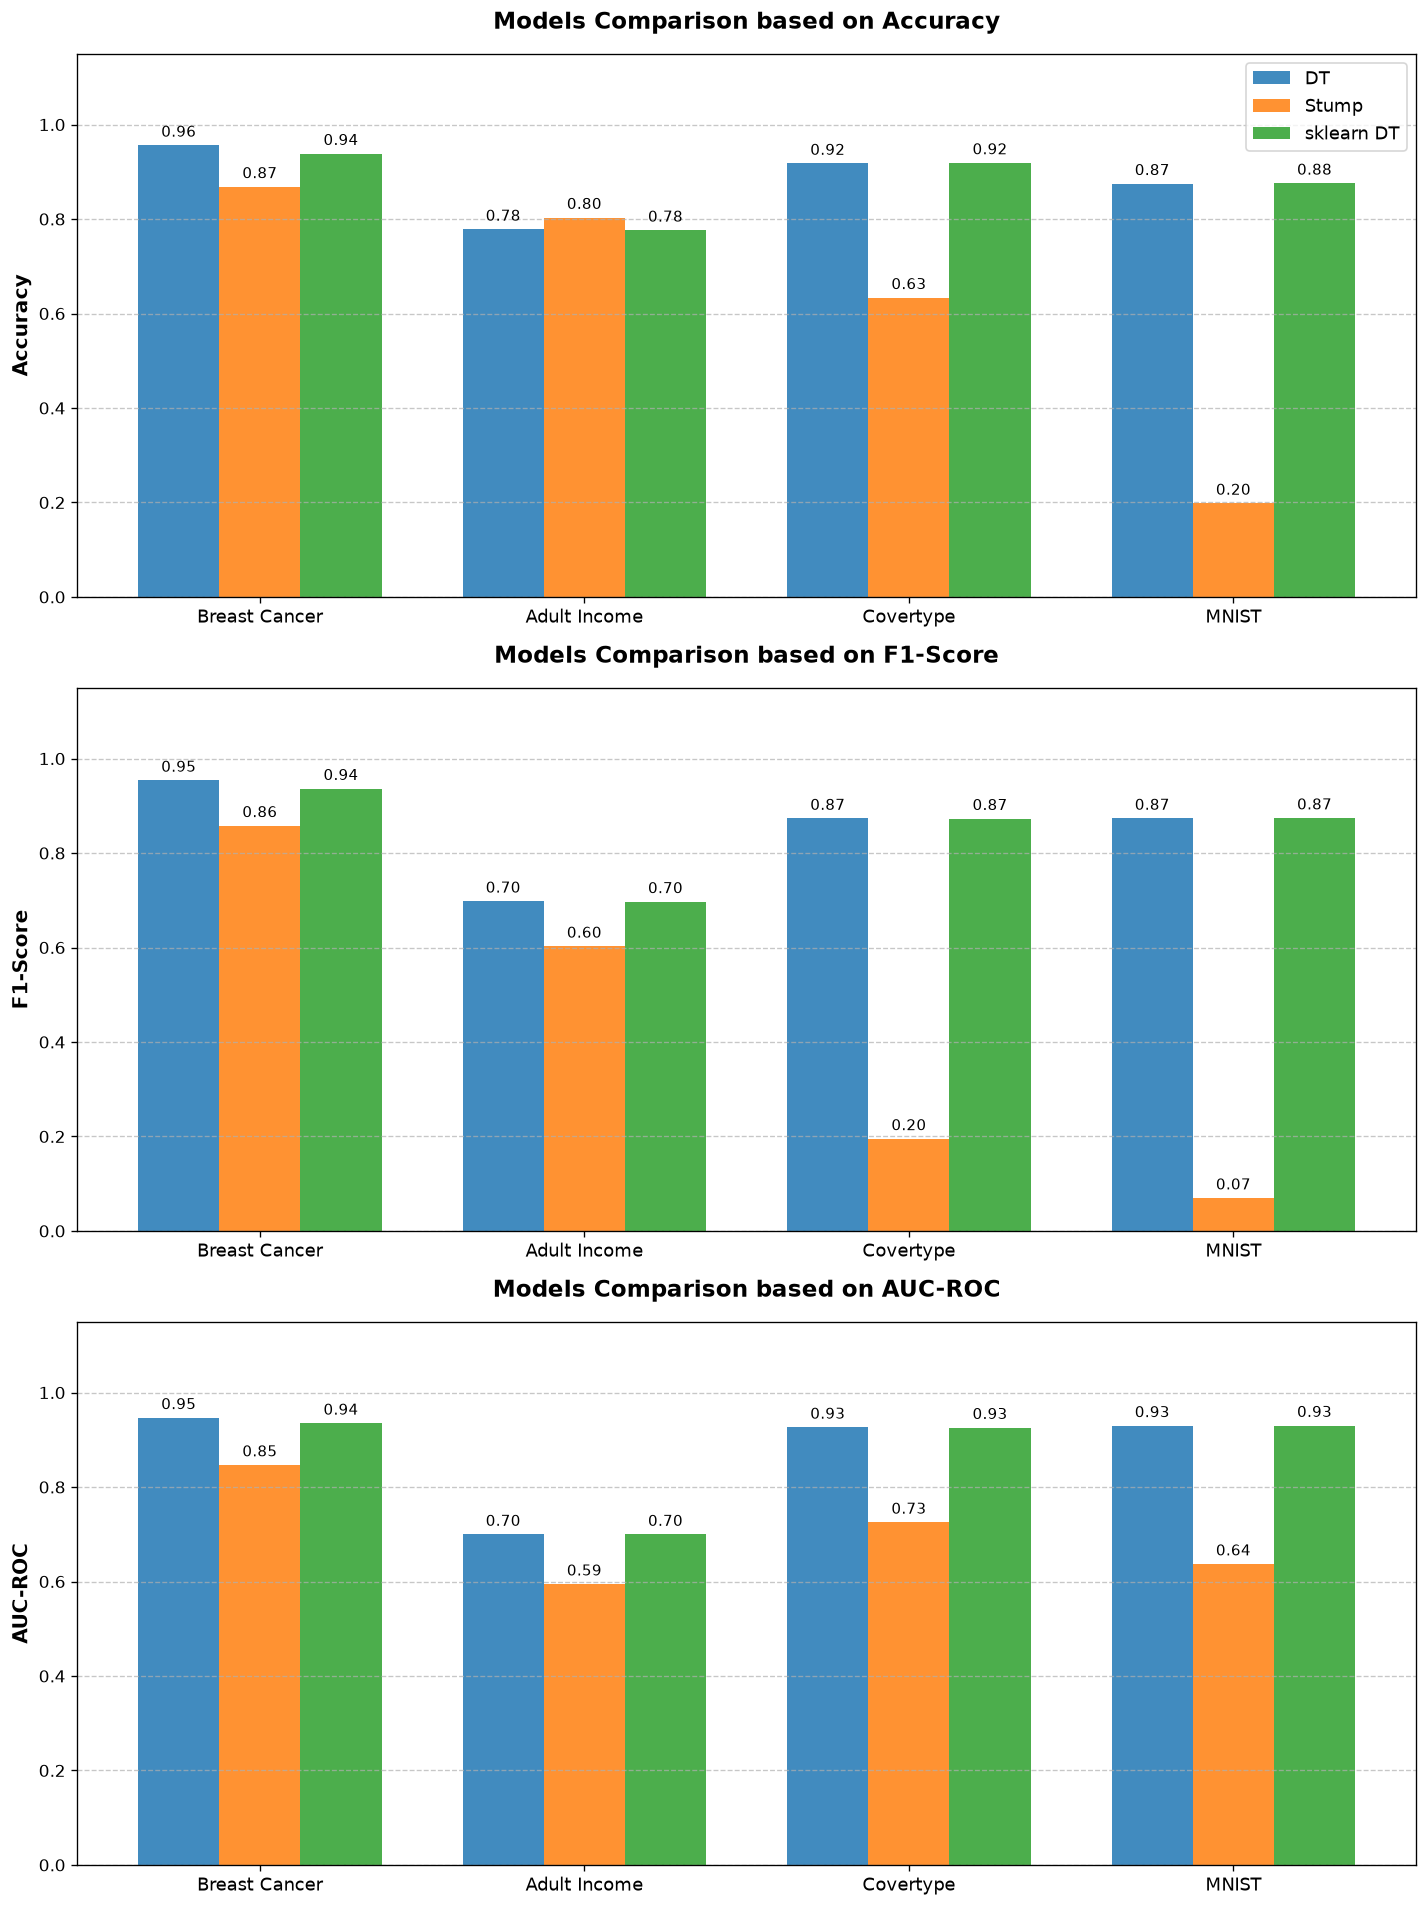

Figure saved to: /Users/student/Desktop/ML_PROJECT-main/figures/baseline_results.png


In [5]:
plot_baseline_results(all_baseline_results)

---
## Summary
Baseline results confirm our DecisionTree matches sklearn within 2%.